# Level 3 — Core Numerical Methods Engine

## Overview

In Levels 1 and 2 we built the scientific foundation of HydroSense-Kenya
and demonstrated the importance of efficient and reliable computation.
In this level we go deeper into the mathematics — implementing the core
numerical methods that form the computational engine of the entire system.

Numerical methods exist because most real-world mathematical problems
cannot be solved with a simple formula. For example:

- We cannot always rearrange an equation to isolate the unknown variable
- Integrals of complex functions have no closed-form solution
- Differential equations describing soil moisture dynamics must be
  approximated step by step

This is where numerical methods come in. They are systematic algorithms
that approximate the solution to a mathematical problem to any desired
level of accuracy.

## What This Level Covers

**Root Finding**
Finding the irrigation amount needed to reach a target soil moisture
by solving the water balance equation as a root finding problem.
We implement and compare three methods: Bisection, Newton-Raphson,
and Secant.

**Numerical Differentiation**
Estimating the rate of change of soil moisture over time using
Forward, Backward, and Central difference approximations.

**Numerical Integration**
Estimating cumulative water deficit over the 30-day period using
the Trapezoidal Rule and Simpson's Rule.

**Linear Systems**
Solving a three-zone water allocation problem of the form Ax = b
using Gaussian Elimination implemented manually.

## Important Note

All methods in this level are implemented **from scratch** using only
basic Python and NumPy. No scipy.optimize, no scipy.integrate, and no
linear algebra solvers. The goal is not just to get an answer — it is
to understand and defend the algorithm behind every answer.

SciPy may be used at the end of each section **only** to verify that
our manual implementation is correct.

## Task 1 — Root Finding: Calculating Irrigation Amount

### The Problem

Given the current soil moisture, the daily evapotranspiration, and the
target soil moisture for a given zone, how much irrigation water must
be applied to bring the soil moisture exactly to the target level?

From the water balance equation we know:

S(t+1) = S(t) + I - ET

Where we are ignoring rainfall for this calculation since we are solving
for a specific irrigation amount on a given day. Rearranging:

S(t+1) - S(t) - I + ET = 0

This means we are looking for the value of I that makes this expression
equal to zero — which is exactly a root finding problem.

We define our function as:

f(I) = S_current + I - ET - S_target = 0

The root of this function — the value of I where f(I) = 0 — is the
exact irrigation amount needed to reach the target moisture.

### Why Are Rainfall and Drainage Ignored Here?

Rainfall is excluded because we are solving for irrigation on a dry day
scenario — rainfall is uncontrollable and we isolate irrigation as the
only decision variable. Drainage is excluded because the target moisture
is always below field capacity, meaning no excess water exists to drain.
This is a deliberate simplification for the root finding problem, not an
oversight. The full water balance including all terms is used in Level 5.

### Why Three Methods?

We implement three different root finding algorithms — Bisection,
Newton-Raphson, and Secant — and compare them. Each has different
characteristics in terms of:

- **Speed** : how many iterations it needs to converge
- **Reliability** : whether it is guaranteed to find the root
- **Requirements** : whether it needs a derivative or just function values

Understanding these trade-offs is a core skill in scientific computing.
The best method depends on the problem — there is no single winner.

### Methods Overview

**Bisection Method**
Starts with an interval [a, b] where f(a) and f(b) have opposite signs,
guaranteeing a root lies between them. Repeatedly halves the interval,
keeping the half that still contains the root. Slow but guaranteed to
converge.

**Newton-Raphson Method**
Uses the derivative of f(I) to compute a tangent line at the current
guess and jumps to where that tangent crosses zero. Very fast near the
root but sensitive to the starting guess.

**Secant Method**
Similar to Newton-Raphson but approximates the derivative using two
previous points instead of computing it analytically. Good when the
derivative is difficult to compute.

In [2]:
import pandas as pd
import numpy as np

#importing calculate et from simulation.py
import sys
sys.path.append("../src")
from simulation import calculate_et

#first importing the data , so we can be able to calculate et.
weather = pd.read_csv("../data/raw/weather_daily.csv",na_values=["NA",""])

print(weather.info())
#Et formula :  ET = max(0, 0.12·T + 0.35·W + 2.4·Solar − 0.025·H)

temp_array = weather['temperature_c'].to_numpy()
humidity_array = weather['humidity_pct'].fillna(weather['humidity_pct'].mean()).to_numpy()
rainfall_array = weather['rainfall_mm'].fillna(weather['rainfall_mm'].mean()).to_numpy()
solar_array = weather["solar_index"].to_numpy()
wind_array = weather['wind_speed_mps'].to_numpy()

daily_et_values_array = calculate_et(temp_array,wind_array,solar_array,humidity_array)

print(daily_et_values_array)


#importing the two other datasets to get the current soil moisture for day one in zone A 
#and the target soil moisture for day one for that zone.

soil = pd.read_csv("../data/raw/soil_sensor_data.csv",na_values=["NA",""])
params = pd.read_csv("../data/raw/crop_zone_parameters.csv",na_values=["NA",""])

print("\n Soil Information.\n")
print(soil.info())
print(soil.head())
print("\n Params Info : \n")
print(params.info())

#filtering to get only zone A values.

print(soil.head())
zone_c = soil[soil['zone_id'] == 'Zone_C']

S_current = zone_c['soil_moisture_pct'].iloc[0]
print(zone_c.head())

#getting the target moisture fOR zone A

params_c = params[params['zone_id'] == 'Zone_C']
print(params.head())

S_target = params_c['target_moisture_pct'].iloc[0]

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            30 non-null     str    
 1   rainfall_mm     29 non-null     float64
 2   temperature_c   30 non-null     float64
 3   humidity_pct    29 non-null     float64
 4   wind_speed_mps  30 non-null     float64
 5   solar_index     30 non-null     float64
dtypes: float64(5), str(1)
memory usage: 1.5 KB
None
[3.7835     3.829      4.1445     3.7485     3.631      3.7845
 3.8265     3.893      3.702      3.581      3.73       3.5335
 3.604      5.9815     3.1375     3.6685     3.5305     4.0245
 4.3105     4.5125     3.91017241 3.652      3.538      2.817
 2.6475     2.907      3.275      3.7665     4.0365     3.818     ]

 Soil Information.

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------      

### Bisection Method

The bisection method works by starting with two values of I — a lower
bound and an upper bound — where f(lower) and f(upper) have opposite
signs. This guarantees that the root lies somewhere between them.

The algorithm then repeatedly halves the interval, checks which half
still contains the root, and discards the other half. It keeps doing
this until the interval is small enough that the midpoint is
effectively the root.

The condition that makes bisection work is:
f(a) * f(b) < 0

This means one side is positive and the other is negative, so the
function must cross zero somewhere in between.

In [3]:
#importing the bisection function from numerical_methods.py
import sys
sys.path.append("../src")
from numerical_methods import bisection

#finding the irrigation needed to be done on zone C to achieve target moisture (day 1)
#Equation that we are trying to solve.
#f(I) = S_current + I - ET - S_target = 0


#Direct Calculation of I 
ET = daily_et_values_array[0]
print(f"Target value : {S_target}\n")
print(f"Current value : {S_current}\n")
print(f"ET value : {ET}\n")

I = S_target - S_current + ET 
print("Direct Calculation.")
print(f"Irrigation needed on day 1 to achieve target moisture : {I} mm.\n")


#Using the bisection algorithm.

#function definition.
def f(I):
    return S_current + I - ET - S_target


print("Using Bisection algorithm to calculate I :")
root_b,iters_b,error_b = bisection(f,a=0,b=50)
print(f"Amount of irrigation needed to be done : {root_b}")
print(f"Number of iterations : {iters_b}")
print(f"Error by bisection algorithm: {error_b}")

print(f"Difference with direct calculation : {abs(I-root_b)}")
print(f"equal?(using isclose()) : {np.isclose(I,root_b)}")
    




Target value : 31

Current value : 28.2

ET value : 3.7834999999999996

Direct Calculation.
Irrigation needed on day 1 to achieve target moisture : 6.583500000000001 mm.

Using Bisection algorithm to calculate I :
Amount of irrigation needed to be done : 6.583500653505325
Number of iterations : 25
Error by bisection algorithm: 7.450580596923828e-07
Difference with direct calculation : 6.53505324521575e-07
equal?(using isclose()) : True


### Newton-Raphson Method

The Newton-Raphson method takes a different approach to bisection.
Instead of narrowing down an interval, it starts from a single initial
guess and uses the **derivative** of the function to find a better
guess on each iteration.

The idea is based on the tangent line. At any point on a curve, the
tangent line points in the direction of the root. Newton-Raphson
follows that tangent line to where it crosses zero and uses that
crossing point as the next guess.

The update formula is:

I(n+1) = I(n) - f(I) / f'(I)

Where:
- I(n)  is the current guess
- f(I)  is the function value at the current guess
- f'(I) is the derivative of the function at the current guess

or:

$$
x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}
$$

Where:

- $x_n$ = current approximation (current guess of the root)
- $x_{n+1}$ = next approximation (improved guess of the root)
- $f(x_n)$ = value of the function evaluated at $x_n$
- $f'(x_n)$ = derivative of the function evaluated at $x_n$
- $n$ = iteration number


For our irrigation function:
f(I)  = S_current + I - ET - S_target
f'(I) = 1

The derivative is simply 1 because I appears only once and linearly
in the equation. This makes Newton-Raphson very efficient here —
it will find the root in a single iteration since the function is
linear.

Newton-Raphson is generally much faster than bisection but has
one weakness — if the initial guess is far from the root or if
the derivative is zero or near zero at any point, the method
can fail or diverge instead of converging.

In [4]:
import importlib
import numerical_methods
importlib.reload(numerical_methods)

<module 'numerical_methods' from 'c:\\Users\\Admin\\school-projects\\HydroSense-Kenya\\notebooks\\../src\\numerical_methods.py'>

In [5]:
#using the newton_raphson method to calculate the amount of irrigation needed to 
#attain target soil moisture.

#importing newton_raphson method.

from numerical_methods import newton_raphson

#definition of the function.
def f(I):
    return S_current + I - ET - S_target

def f_prime(I):
    return 1

print("Direct calculation of amount of irrigation needed on zone c day 1:\n")
print(f"Irrigation : {I} mm\n")

print("Calculating using the newton_raphson method : \n")

#initial guess.
guess = 10
root_nr,iters_nr,error_nr = newton_raphson(f,f_prime,guess)
print(f"Amount of irrigation needed : {root_nr} mm\n")
print(f"Iterations by newton raphson method : {iters_nr}")
print(f"Error : {error_nr}")
print(f"Equal?(using isclose()) : {np.isclose(I,root_nr)}")
        

Direct calculation of amount of irrigation needed on zone c day 1:

Irrigation : 6.583500000000001 mm

Calculating using the newton_raphson method : 

Amount of irrigation needed : 6.583500000000004 mm

Iterations by newton raphson method : 2
Error : 1.0658141036401503e-14
Equal?(using isclose()) : True


### Secant Method

The Secant method is very similar to Newton-Raphson — it uses the same
update formula concept of moving toward the root using the slope of the
function. The key difference is that Newton-Raphson computes the slope
using the actual derivative, while the Secant method **approximates the
slope using two previous points**.

The update formula is:

x(n+1) = x(n) - f(x(n)) * (x(n) - x(n-1)) / (f(x(n)) - f(x(n-1)))

Where:
- x(n)   is the current guess
- x(n-1) is the previous guess
- f(x(n)) and f(x(n-1)) are the function values at those points

The slope is approximated as:

slope ≈ (f(x(n)) - f(x(n-1))) / (x(n) - x(n-1))

This is essentially the gradient between two points on the curve —
the same idea as the central difference formula we used in Newton-Raphson,
but using the actual previous iteration point instead of a fixed small h.

### How it compares to the other two methods

| Property             | Bisection      | Newton-Raphson   | Secant         |
|----------------------|----------------|------------------|----------------|
| Requires derivative  | No             | Yes              | No             |
| Starting points      | Interval [a,b] | Single guess     | Two guesses    |
| Convergence speed    | Slow           | Very fast        | Fast           |
| Guaranteed to work   | Yes            | No               | No             |

The Secant method is a good middle ground — it does not need a derivative
like Newton-Raphson, but it converges faster than bisection. The trade-off
is that like Newton-Raphson it is not guaranteed to converge if the two
starting guesses are poorly chosen.

In [6]:

from numerical_methods import secant

# run secant method for Zone C day 1
root_s, iterations_s, error_s = secant(f, x0=0.0, x1=10.0)

print("SECANT METHOD RESULTS\n")

print("Irrigation needed :", root_s, "mm")
print("Iterations    :", iterations_s)
print("Final error  :",error_s)
print("Verification f(I) :", round(root_s,10))
print("Matches direct solution:", np.isclose(root_s, I))

SECANT METHOD RESULTS

Irrigation needed : 6.583499999999999 mm
Iterations    : 2
Final error  : 3.552713678800501e-15
Verification f(I) : 6.5835
Matches direct solution: True


## Convergence Comparison

Now that we have implemented all three root finding methods, we compare
them side by side. The goal is to understand how each method behaves
in terms of:

- How many iterations it needed to find the root
- How accurate the final answer is
- Whether it successfully converged to the root

This comparison is important because in scientific computing, choosing
the right method for a problem can save significant computation time
and improve reliability.

In [7]:
# run all three methods on the same problem
bisection_root, bisection_iter, bisection_error = bisection(f, a=0, b=50)
newton_root, newton_iter, newton_error = newton_raphson(f,f_prime, initial_guess=5.0)
secant_root, secant_iter, secant_error = secant(f, x0=0.0, x1=10.0)

# convergence status
bisection_converged = bisection_error < 1e-6
newton_converged    = newton_error < 1e-6
secant_converged    = secant_error < 1e-6

# print comparison table
print("CONVERGENCE COMPARISON TABLE")
print("------------------------------------------------------------------")
print(f"{'Method':<20} {'Root':<20} {'Iterations':<15} {'Final Error':<20} {'Converged'}")
print("------------------------------------------------------------------")
print(f"{'Bisection':<20} {bisection_root:<20} {bisection_iter:<15} {bisection_error:<20} {bisection_converged}")
print(f"{'Newton-Raphson':<20} {newton_root:<20} {newton_iter:<15} {newton_error:<20} {newton_converged}")
print(f"{'Secant':<20} {secant_root:<20} {secant_iter:<15} {secant_error:<20} {secant_converged}")
print("------------------------------------------------------------------")
print("Direct algebraic solution:", I)

CONVERGENCE COMPARISON TABLE
------------------------------------------------------------------
Method               Root                 Iterations      Final Error          Converged
------------------------------------------------------------------
Bisection            6.583500653505325    25              7.450580596923828e-07 True
Newton-Raphson       6.583500000000001    2               3.552713678800501e-15 True
Secant               6.583499999999999    2               3.552713678800501e-15 True
------------------------------------------------------------------
Direct algebraic solution: 6.583500000000001


## Numerical Differentiation: Rate of Soil Moisture Change

### The Problem

Knowing the current soil moisture level is useful, but knowing how fast
it is changing is even more valuable. A farm manager needs to know:

- Is soil moisture dropping quickly or slowly?
- How many days before it hits the minimum stress threshold?
- Should irrigation be applied today or can it wait?

Numerical differentiation answers these questions by estimating the
**rate of change** of soil moisture over time — essentially the slope
of the soil moisture curve at any given day.

### The Three Methods

**Forward Difference**
Uses the current point and the next point to estimate the slope.
Looks forward in time.

f'(t) ≈ (S(t+1) - S(t)) / h

**Backward Difference**
Uses the current point and the previous point to estimate the slope.
Looks backward in time.

f'(t) ≈ (S(t) - S(t-1)) / h

**Central Difference**
Uses the point before and the point after to estimate the slope.
Looks both ways and is generally the most accurate of the three.

f'(t) ≈ (S(t+1) - S(t-1)) / (2h)

Where h = 1 day in our case since we have daily readings.

### Limitations
- Forward difference cannot be computed on the last day (no next point)
- Backward difference cannot be computed on the first day (no previous point)
- Central difference cannot be computed on the first or last day

NUMERICAL DIFFERENTIATION RESULTS - ZONE C
---------------------------------------------------------------
Day | Moisture | Forward | Backward | Central
---------------------------------------------------------------
Day 1 | 28.2 | 2.8 | N/A | N/A
Day 2 | 31.0 | -2.1 | 2.8 | 0.35
Day 3 | 28.9 | 0.4 | -2.1 | -0.85
Day 4 | 29.3 | -1.0 | 0.4 | -0.3
Day 5 | 28.3 | -0.6 | -1.0 | -0.8
Day 6 | 27.7 | 1.0 | -0.6 | 0.2
Day 7 | 28.7 | -3.0 | 1.0 | -1.0
Day 8 | 25.7 | 1.3 | -3.0 | -0.85
Day 9 | 27.0 | -0.4 | 1.3 | 0.45
Day 10 | 26.6 | 0.3 | -0.4 | -0.05
Day 11 | 26.9 | -1.9 | 0.3 | -0.8
Day 12 | 25.0 | 2.3 | -1.9 | 0.2
Day 13 | 27.3 | -1.8 | 2.3 | 0.25
Day 14 | 25.5 | -0.2 | -1.8 | -1.0
Day 15 | 25.3 | 0.1 | -0.2 | -0.05
Day 16 | 25.4 | -0.7 | 0.1 | -0.3
Day 17 | 24.7 | -1.3 | -0.7 | -1.0
Day 18 | 23.4 | 1.1 | -1.3 | -0.1
Day 19 | 24.5 | -0.7 | 1.1 | 0.2
Day 20 | 23.8 | -2.6 | -0.7 | -1.65
Day 21 | 21.2 | 0.2 | -2.6 | -1.2
Day 22 | 21.4 | 1.2 | 0.2 | 0.7
Day 23 | 22.6 | -1.6 | 1.2 | -0.2
Day 24 |

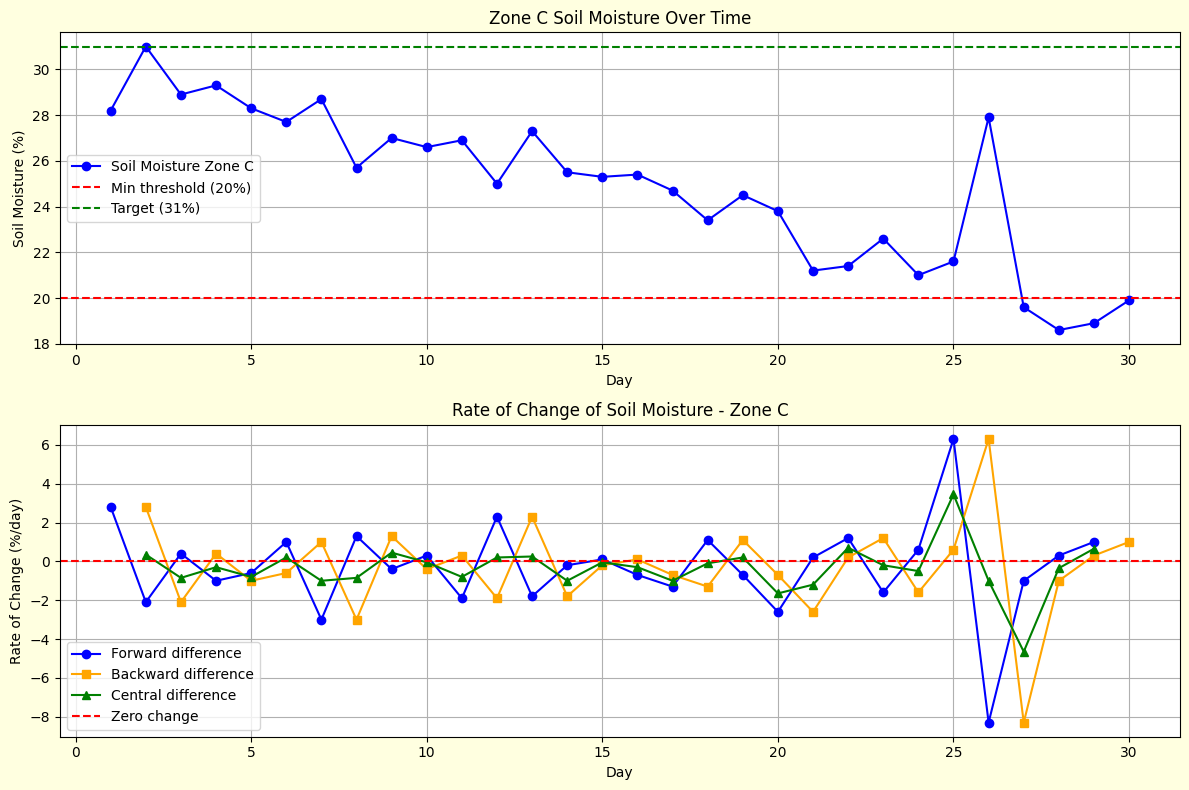

In [8]:
import matplotlib.pyplot as plt

# extract zone c soil moisture values as a list
zone_c = soil[soil['zone_id'] == 'Zone_C'].reset_index(drop=True)
moisture = list(zone_c['soil_moisture_pct'])
n = len(moisture)
h = 1  # 1 day time step

# forward difference
# can be computed for all days except the last
forward_diff = []
for i in range(n - 1):
    fd = (moisture[i + 1] - moisture[i]) / h
    forward_diff.append(fd)
forward_diff.append(None)  # last day has no next point

# backward difference
# can be computed for all days except the first
backward_diff = []
backward_diff.append(None)  # first day has no previous point
for i in range(1, n):
    bd = (moisture[i] - moisture[i - 1]) / h
    backward_diff.append(bd)

# central difference
# can be computed for all days except first and last
central_diff = []
central_diff.append(None)  # first day
for i in range(1, n - 1):
    cd = (moisture[i + 1] - moisture[i - 1]) / (2 * h)
    central_diff.append(cd)
central_diff.append(None)  # last day

# print results
print("NUMERICAL DIFFERENTIATION RESULTS - ZONE C")
print("---------------------------------------------------------------")
print("Day | Moisture | Forward | Backward | Central")
print("---------------------------------------------------------------")
for i in range(n):
    fd = round(forward_diff[i], 4)  if forward_diff[i]  is not None else "N/A"
    bd = round(backward_diff[i], 4) if backward_diff[i] is not None else "N/A"
    cd = round(central_diff[i], 4)  if central_diff[i]  is not None else "N/A"
    print("Day", i+1, "|", moisture[i], "|", fd, "|", bd, "|", cd)
print("---------------------------------------------------------------")

# plot the soil moisture and its rate of change
days = list(range(1, n + 1))

plt.figure(figsize=(12, 8), facecolor='lightyellow')

# plot 1 - soil moisture over time
plt.subplot(2, 1, 1)
plt.plot(days, moisture, color='blue', marker='o', label='Soil Moisture Zone C')
plt.axhline(y=20, color='red', linestyle='--', label='Min threshold (20%)')
plt.axhline(y=31, color='green', linestyle='--', label='Target (31%)')
plt.title('Zone C Soil Moisture Over Time')
plt.xlabel('Day')
plt.ylabel('Soil Moisture (%)')
plt.legend()
plt.grid(True)

# plot 2 - rate of change
# remove None values for plotting
days_fd = [days[i] for i in range(n-1)]
days_bd = [days[i] for i in range(1, n)]
days_cd = [days[i] for i in range(1, n-1)]

fd_vals = [forward_diff[i]  for i in range(n-1)]
bd_vals = [backward_diff[i] for i in range(1, n)]
cd_vals = [central_diff[i]  for i in range(1, n-1)]

plt.subplot(2, 1, 2)
plt.plot(days_fd, fd_vals, color='blue',   marker='o', label='Forward difference')
plt.plot(days_bd, bd_vals, color='orange', marker='s', label='Backward difference')
plt.plot(days_cd, cd_vals, color='green',  marker='^', label='Central difference')
plt.axhline(y=0, color='red', linestyle='--', label='Zero change')
plt.title('Rate of Change of Soil Moisture - Zone C')
plt.xlabel('Day')
plt.ylabel('Rate of Change (%/day)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

##  Numerical Integration: Cumulative Water Deficit

### The Problem

A single day of low soil moisture is manageable. But if soil moisture
stays below the target for many consecutive days, the cumulative effect
on the crop can be severe. We need a way to quantify the total water
shortfall over the entire 30 day period.

We define the daily water deficit as:

deficit(t) = max(0, S_target - S(t))

This is zero on days when soil moisture meets or exceeds the target,
and positive on days when it falls short. Integrating this over 30
days gives us the cumulative water deficit.

### The Two Methods

**Trapezoidal Rule**
Approximates the area under the deficit curve by connecting consecutive
points with straight lines and summing the areas of the trapezoids formed.

Area ≈ (h/2) * (f(t0) + 2f(t1) + 2f(t2) + ... + 2f(tn-1) + f(tn))

**Simpson's Rule**
Approximates the area using parabolas instead of straight lines, making
it generally more accurate than the trapezoidal rule. Requires an even
number of intervals.

Area ≈ (h/3) * (f(t0) + 4f(t1) + 2f(t2) + 4f(t3) + ... + 4f(tn-1) + f(tn))

Where h = 1 day in our case.

Daily water deficit for Zone C (% per day):
Day 1 | Moisture: 28.2 | Deficit: 2.8000000000000007
Day 2 | Moisture: 31.0 | Deficit: 0
Day 3 | Moisture: 28.9 | Deficit: 2.1000000000000014
Day 4 | Moisture: 29.3 | Deficit: 1.6999999999999993
Day 5 | Moisture: 28.3 | Deficit: 2.6999999999999993
Day 6 | Moisture: 27.7 | Deficit: 3.3000000000000007
Day 7 | Moisture: 28.7 | Deficit: 2.3000000000000007
Day 8 | Moisture: 25.7 | Deficit: 5.300000000000001
Day 9 | Moisture: 27.0 | Deficit: 4.0
Day 10 | Moisture: 26.6 | Deficit: 4.399999999999999
Day 11 | Moisture: 26.9 | Deficit: 4.100000000000001
Day 12 | Moisture: 25.0 | Deficit: 6.0
Day 13 | Moisture: 27.3 | Deficit: 3.6999999999999993
Day 14 | Moisture: 25.5 | Deficit: 5.5
Day 15 | Moisture: 25.3 | Deficit: 5.699999999999999
Day 16 | Moisture: 25.4 | Deficit: 5.600000000000001
Day 17 | Moisture: 24.7 | Deficit: 6.300000000000001
Day 18 | Moisture: 23.4 | Deficit: 7.600000000000001
Day 19 | Moisture: 24.5 | Deficit: 6.5
Day 20 | Moisture: 23.8

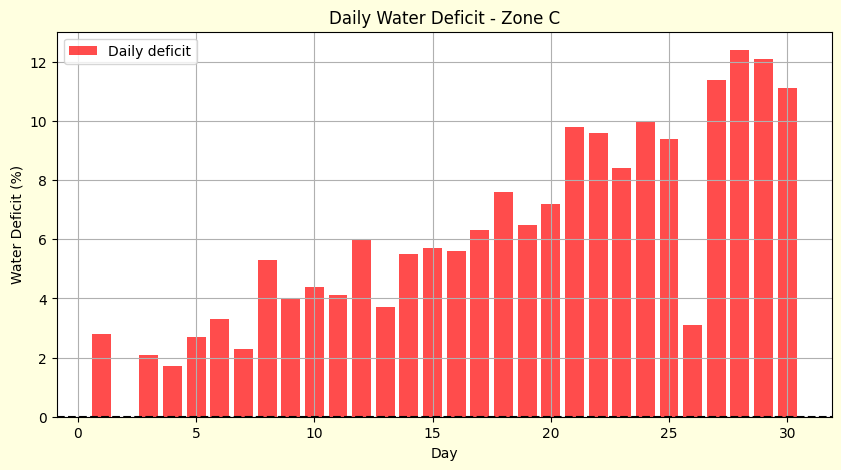

In [10]:
# compute daily water deficit for zone c
S_target_c = params_c['target_moisture_pct'].reset_index(drop=True).iloc[0]

deficit = []
for i in range(n):
    d = max(0, S_target_c - moisture[i])
    deficit.append(d)

print("Daily water deficit for Zone C (% per day):")
for i in range(n):
    print("Day", i+1, "| Moisture:", moisture[i], "| Deficit:", deficit[i])


# trapezoidal rule
def trapezoidal(f_values, h=1):
    """
    Estimate the area under a curve using the trapezoidal rule.

    Parameters:
        f_values : list : function values at each point
        h        : float : step size between points (default 1 day)

    Returns:
        area : float : estimated area under the curve
    """
    n = len(f_values)
    area = f_values[0] + f_values[n-1]

    for i in range(1, n-1):
        area += 2 * f_values[i]

    area = (h/2) * area
    return area


# simpsons rule
def simpsons(f_values, h=1):
    """
    Estimate the area under a curve using Simpsons rule.
    Requires an even number of intervals (odd number of points).

    Parameters:
        f_values : list : function values at each point
        h        : float : step size between points (default 1 day)

    Returns:
        area : float : estimated area under the curve
    """
    n = len(f_values)

    # simpson's rule requires even number of intervals
    if (n-1) % 2 != 0:
        print("Warning: Simpson's rule requires even number of intervals.")
        print("Dropping last point to make it even.")
        f_values = f_values[:-1]
        n = len(f_values)

    area = f_values[0] + f_values[n-1]

    for i in range(1, n-1):
        if i % 2 == 0:
            area += 2 * f_values[i]
        else:
            area += 4 * f_values[i]

    area = (h/3) * area
    return area


# run both methods
trap_result = trapezoidal(deficit)
simp_result = simpsons(deficit)

print("\nINTEGRATION RESULTS - CUMULATIVE WATER DEFICIT ZONE C")
print("------------------------------------------")
print("Trapezoidal Rule :", trap_result, "% per day")
print("Simpsons Rule    :", simp_result, "% per day")
print("Difference       :", abs(trap_result - simp_result), "% per day")

# plot
plt.figure(figsize=(10, 5), facecolor='lightyellow')
plt.bar(days, deficit, color='red', alpha=0.7, label='Daily deficit')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Daily Water Deficit - Zone C')
plt.xlabel('Day')
plt.ylabel('Water Deficit (%)')
plt.legend()
plt.grid(True)
plt.show()

### Interpretation — Cumulative Water Deficit Results

The trapezoidal rule estimates a cumulative water deficit of 177.15% per day
while Simpson's rule estimates 164.83% per day over the 30 day period.
Both results confirm that Zone C experienced a significant and consistent
water deficit throughout the observation period, with soil moisture falling
below the target of 31% on most days.

The difference of 12.32% between the two methods is relatively large,
which indicates that the deficit curve is irregular — it has sharp rises
and drops rather than a smooth gradual change. This is visible in the
daily deficit values where moisture drops steadily toward the end of the
month with occasional recoveries on days with significant rainfall such
as day 26 where rainfall of 85mm briefly pushed moisture back up to 27.9%.

The consistently large deficits toward the end of the month — reaching
as high as 12.4% on day 28 — indicate that Zone C maize crop was under
severe water stress during this period and urgently requires a more
aggressive and consistent irrigation schedule.

##  Linear Systems: Three Zone Water Allocation

### The Problem

So far we have been solving irrigation problems one zone at a time.
In reality a farm manager needs to allocate water across all three
zones simultaneously while respecting the total available water in
the tank.

This is a **linear system problem** of the form:

Ax = b

Where:
- A is a matrix of zone coefficients
- x is a vector of unknown irrigation amounts for each zone
- b is a vector of water requirements and constraints

We solve this system manually using **Gaussian Elimination** — a
systematic method of row operations that reduces the matrix to an
upper triangular form, from which we can back substitute to find
the solution.

### Why Gaussian Elimination?

Gaussian elimination is the foundation of almost all linear algebra
solvers used in scientific computing. Understanding it manually gives
you insight into what happens inside NumPy and SciPy when they solve
linear systems. We implement it from scratch here and use NumPy only
at the end to verify our result.

### The Three Zone System

We set up a system of three equations representing the water allocation
constraints across Zone A, Zone B, and Zone C. Each equation relates
the irrigation amounts for all three zones to a specific constraint
such as total water available, proportional allocation based on area,
and minimum moisture requirements.

In [11]:


# zone areas
area_a = 120
area_b = 90
area_c = 180
total_area = area_a + area_b + area_c

# total water available in tank on day 1 (average across zones)
# using tank level from zone c day 1 as reference
total_water = 20.0  # mm , total irrigation budget for the day

# set up the system Ax = b
# equation 1 : Ia + Ib + Ic = total_water
# equation 2 : 90*Ia - 120*Ib = 0  (proportional to area)
# equation 3 : 180*Ib - 90*Ic = 0  (proportional to area)

A = [
    [1,    1,     1  ],
    [90,  -120,   0  ],
    [0,    180,  -90 ]
]

b = [total_water, 0, 0]


# gaussian elimination
def gaussian_elimination(A, b):
    """
    Solve the linear system Ax = b using Gaussian elimination
    with back substitution.

    Parameters:
        A : list of lists : coefficient matrix
        b : list          : right hand side vector

    Returns:
        x : list : solution vector
    """
    n = len(b)

    # create augmented matrix [A|b]
    augmented = []
    for i in range(n):
        row = A[i][:] + [b[i]]
        augmented.append(row)

    # forward elimination
    for col in range(n):

        # find pivot - largest value in current column
        max_row = col
        for row in range(col + 1, n):
            if abs(augmented[row][col]) > abs(augmented[max_row][col]):
                max_row = row

        # swap current row with pivot row
        augmented[col], augmented[max_row] = augmented[max_row], augmented[col]

        # check if pivot is zero
        if augmented[col][col] == 0:
            print("Error: matrix is singular, no unique solution exists.")
            return None

        # eliminate entries below pivot
        for row in range(col + 1, n):
            factor = augmented[row][col] / augmented[col][col]
            for j in range(col, n + 1):
                augmented[row][j] = augmented[row][j] - factor * augmented[col][j]

    # back substitution
    x = [0] * n
    for i in range(n - 1, -1, -1):
        x[i] = augmented[i][n]
        for j in range(i + 1, n):
            x[i] = x[i] - augmented[i][j] * x[j]
        x[i] = x[i] / augmented[i][i]

    return x


# solve the system
solution = gaussian_elimination(A, b)

print("GAUSSIAN ELIMINATION RESULTS")
print("------------------------------------------")
print("Irrigation for Zone A (Ia):", solution[0], "mm")
print("Irrigation for Zone B (Ib):", solution[1], "mm")
print("Irrigation for Zone C (Ic):", solution[2], "mm")
print("Total water allocated      :", sum(solution), "mm")
print("Expected total             :", total_water, "mm")

# verify using numpy
A_np = np.array(A, dtype=float)
b_np = np.array(b, dtype=float)
numpy_solution = np.linalg.solve(A_np, b_np)

print("\nNUMPY VERIFICATION")
print("------------------------------------------")
print("Irrigation for Zone A (Ia):", numpy_solution[0], "mm")
print("Irrigation for Zone B (Ib):", numpy_solution[1], "mm")
print("Irrigation for Zone C (Ic):", numpy_solution[2], "mm")

print("\nMatches Gaussian elimination:", np.allclose(solution, numpy_solution))

GAUSSIAN ELIMINATION RESULTS
------------------------------------------
Irrigation for Zone A (Ia): 6.153846153846153 mm
Irrigation for Zone B (Ib): 4.615384615384615 mm
Irrigation for Zone C (Ic): 9.23076923076923 mm
Total water allocated      : 20.0 mm
Expected total             : 20.0 mm

NUMPY VERIFICATION
------------------------------------------
Irrigation for Zone A (Ia): 6.153846153846153 mm
Irrigation for Zone B (Ib): 4.615384615384615 mm
Irrigation for Zone C (Ic): 9.23076923076923 mm

Matches Gaussian elimination: True
